# Analysis
## Prep

In [34]:
# Import necessary libraries
from datetime import datetime, timedelta

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import json

plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.serif"] = ["Times New Roman"]


# Load our results
with open(os.path.join("..", "dataset", "results.json"), "r", encoding="utf-8") as f:
    data = json.load(f)

def time_to_seconds(time_str) -> int:
    """
    Converts a time string in 'MM:SS' format to total seconds.
    """
    try:
        # Detect format based on number of colons
        if time_str.count(':') == 1:
            fmt = "%M:%S"
        else:
            raise ValueError("Invalid time format")
        
        dt = datetime.strptime(time_str, fmt)
        # Convert to total seconds
        td = timedelta(hours=dt.hour, minutes=dt.minute, seconds=dt.second)
        return int(td.total_seconds())
    except ValueError:
        raise ValueError("Invalid time string. Use 'MM:SS' format")


## Claim #2

In [35]:

rows_2nd_claim = []

for record in data:
    last = record["DetectionResults"][-1]
    rows_2nd_claim.append({
        "Id": record["Id"],
        "Is": record["Is"],
        "Human": 1 if record["HumanClassification"] == "Fraud" else 0,
        "Naive": 1 if last["NaiveClassification"]["Flag"] == "Fraud" else 0,
        "Enhanced": 1 if last["EnhancedClassification"]["Flag"] == "Fraud" else 0,
        "Duration-mean": time_to_seconds(record["RealDuration"]),
        "Duration-median": time_to_seconds(record["RealDuration"])
    })

df2 = pd.DataFrame(rows_2nd_claim)
groupby_2nd_claim = df2.groupby("Is").aggregate({
    "Id": "count",
    "Human": "sum",
    "Naive": "sum",
    "Enhanced": "sum",
    "Duration-mean": "mean",
    "Duration-median": "median",
})
groupby_2nd_claim.columns = ['Total', 'Human', 'Naive', 'Enhanced', 'Duration (mean)', 'Duration (median)']
result_2nd_claim = groupby_2nd_claim.round(decimals=2)
print (result_2nd_claim)


       Total  Human  Naive  Enhanced  Duration (mean)  Duration (median)
Is                                                                      
Fraud    176     52    113        87           107.05               94.5
Safe     173      0      0         2           121.27              127.0


## Claim #4 

In [36]:
rows_4th_claim = []

for record in data:
    for subrecord in record["DetectionResults"]:
        rows_4th_claim.append({
            "Id": record["Id"],
            "Naive detector": subrecord["NaiveClassification"]["Duration"],
            "Enhanced detector": subrecord["EnhancedClassification"]["Duration"]
        })

df4 = pd.DataFrame(rows_4th_claim)
df4.describe().round(2)

,Naive detector,Enhanced detector
count,3961.00,3961.00
mean,5.11,9.32
std,3.19,3.17
min,1.26,2.49
25%,2.99,7.19
50%,3.95,9.30
75%,6.15,11.26
max,28.80,31.36


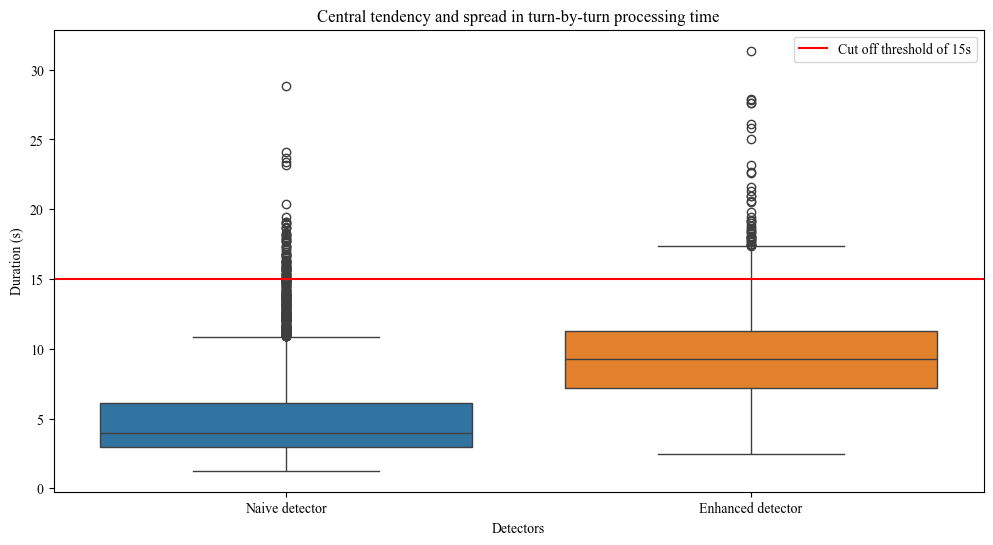

In [37]:
# Boxplot to identify outliers
plt.figure(figsize=(12, 6))
bxp = sns.boxplot(data=df4.drop('Id', axis=1))
ax = plt.subplot(111)
ax.axhline(y = 15, color = 'r', label = 'Cut off threshold of 15s')
ax.set_xlabel("Detectors")
ax.set_ylabel("Duration (s)")
plt.legend()
plt.title('Central tendency and spread in turn-by-turn processing time')
plt.show()

### What does all those outliers tell us?

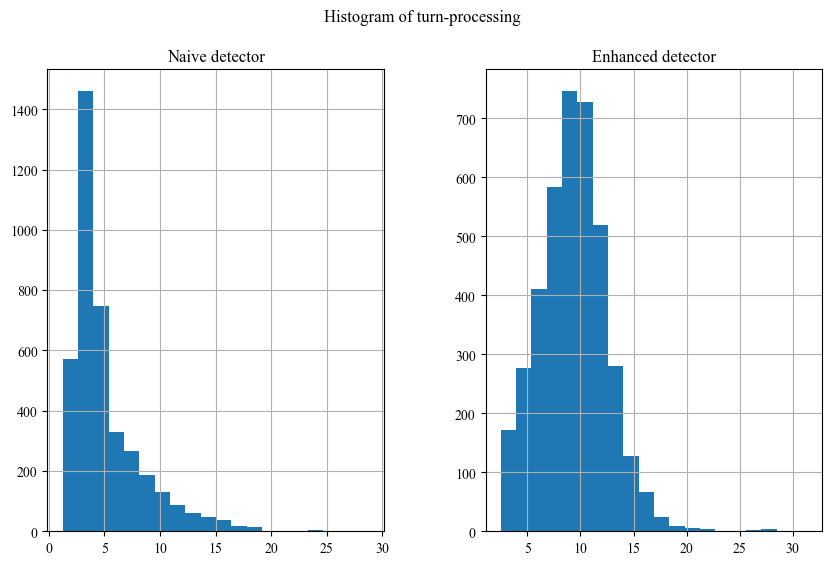

In [38]:
# Histogram for each feature
hist = df4.drop('Id', axis=1).hist(figsize=(10, 6), bins=20)
plt.suptitle('Histogram of turn-processing')
plt.show()

## Claim 2

In [ ]:
def aggregate_prediction(detection_results, model_key):
    """
    Rule: if the last utterance is Fraud then it is Fraud. Otherwise is safe.
    """
    if detection_results[-1][model_key]["Flag"] == "Fraud":
        return "Fraud"
    return "Safe"

def compute_metrics(calls, predictor_fn):
    TP = FP = TN = FN = 0

    # ground truth
    for call in calls:
        y_true = call["Is"] 
        y_pred = predictor_fn(call) 

        if y_true == "Fraud" and y_pred == "Fraud":
            TP += 1
        elif y_true == "Safe" and y_pred == "Fraud":
            FP += 1
        elif y_true == "Safe" and y_pred == "Safe":
            TN += 1
        elif y_true == "Fraud" and y_pred == "Safe":
            FN += 1

    accuracy = round((TP + TN) / (TP + TN + FP + FN), 2)
    precision = round(TP / (TP + FP), 2)
    recall = round(TP / (TP + FN), 2)
    f1 = round((2 * precision * recall) / (precision + recall), 2)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN
    }


def naive_predictor(json_data):
    return aggregate_prediction(
        json_data["DetectionResults"],
        "NaiveClassification"
    )

def enhanced_predictor(json_data):
    return aggregate_prediction(
        json_data["DetectionResults"],
        "EnhancedClassification"
    )

def human_predictor(json_data):
    return json_data["HumanClassification"]

results = {
    "Naive": [],
    "Enhanced": [],
    "Human": []
}

metrics_naive = compute_metrics(data, naive_predictor)
metrics_enhanced = compute_metrics(data, enhanced_predictor)
metrics_human = compute_metrics(data, human_predictor)

def average_metrics(metrics_list):
    return {
        k: sum(m[k] for m in metrics_list) / len(metrics_list)
        for k in metrics_list[0]
    }

df3 = pd.DataFrame(
    [metrics_naive, metrics_enhanced, metrics_human],
    index=["Naive detector", "Enhanced detector", "Trained human baseline"]
)[["Accuracy", "Precision", "Recall", "F1-score"]]
print(df3)

                        Accuracy  Precision  Recall  F1-score
Naive detector              0.82       1.00    0.64      0.78
Enhanced detector           0.74       0.98    0.49      0.65
Trained human baseline      0.64       1.00    0.30      0.46


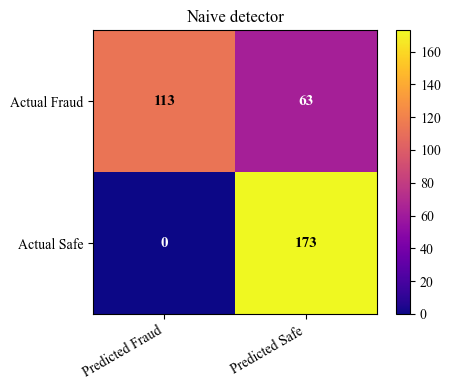

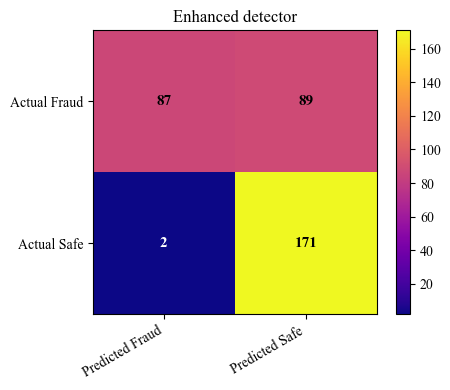

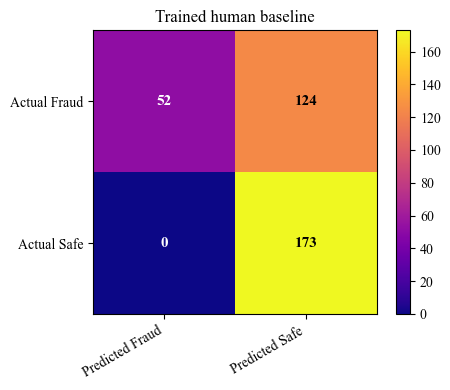

In [40]:
def confusion_df(metrics):
    """
    Build a 2x2 confusion matrix DataFrame from metrics dict.
    """
    return pd.DataFrame(
        [[metrics["TP"], metrics["FN"]],
         [metrics["FP"], metrics["TN"]]],
        index=["Actual Fraud", "Actual Safe"],
        columns=["Predicted Fraud", "Predicted Safe"]
    )

def plot_confusion_heatmap(conf_df, title):
    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(conf_df.values, cmap="plasma")

    ax.set_xticks(np.arange(len(conf_df.columns)))
    ax.set_yticks(np.arange(len(conf_df.index)))
    ax.set_xticklabels(conf_df.columns)
    ax.set_yticklabels(conf_df.index)

    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # for the contrast
    threshold = conf_df.values.max() / 2

    for i in range(conf_df.shape[0]):
        for j in range(conf_df.shape[1]):
            value = conf_df.iloc[i, j]
            ax.text(
                j, i,
                value,
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="black" if value > threshold else "white"
            )

    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

conf_naive = confusion_df(metrics_naive)
conf_enhanced = confusion_df(metrics_enhanced)
conf_human = confusion_df(metrics_human)

plot_confusion_heatmap(conf_naive, "Naive detector")
plot_confusion_heatmap(conf_enhanced, "Enhanced detector")
plot_confusion_heatmap(conf_human, "Trained human baseline")

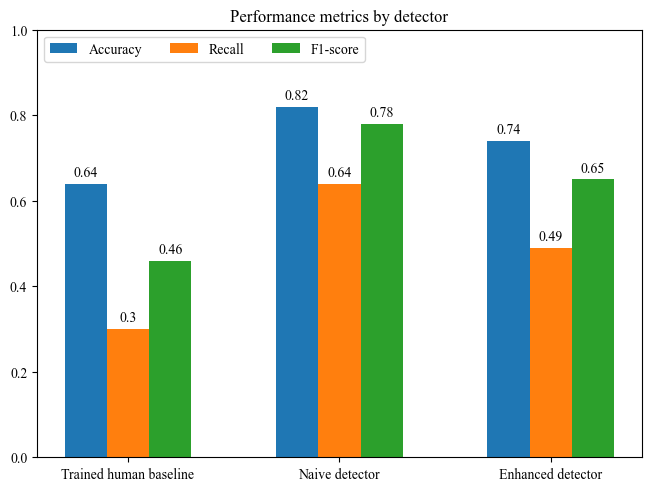

In [51]:
species = ("Trained human baseline", "Naive detector", "Enhanced detector")
penguin_means = {
    'Accuracy': (metrics_human["Accuracy"], metrics_naive["Accuracy"], metrics_enhanced["Accuracy"]),
    'Recall': (metrics_human["Recall"], metrics_naive["Recall"], metrics_enhanced["Recall"]),
    'F1-score': (metrics_human["F1-score"], metrics_naive["F1-score"], metrics_enhanced["F1-score"]),
}

x = np.arange(len(species))  # the label locations
width = 0.20  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_title('Performance metrics by detector')
ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1)

plt.show()